In [116]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

In [117]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, cohen_kappa_score, log_loss

def report_metrics(y_true, y_pred, y_prob=None, label="", average="weighted"):
    """
    Report classification metrics for a multiclass classifier.

    Args:
        y_true: Ground truth labels
        y_pred: Predicted labels
        y_prob: Predicted probabilities for all classes (shape: n_samples x n_classes, needed for AUC)
        label: Optional label for the report (e.g. "Train", "Test")
        average: Averaging strategy for precision/recall/f1 ("weighted", "macro", "micro")
    """
    error    = 1 - accuracy_score(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    prec     = precision_score(y_true, y_pred, average=average, zero_division=0)
    rec      = recall_score(y_true, y_pred, average=average, zero_division=0)
    f1       = f1_score(y_true, y_pred, average=average, zero_division=0)
    cohen    = cohen_kappa_score(y_true, y_pred)

    if y_prob is not None:
        auc = roc_auc_score(y_true, y_prob, multi_class="ovr", average=average)
        cross_en = log_loss(y_true, y_prob)
    else:
        auc = "N/A (provide y_prob)"
        cross_en = "N/A (provide y_prob)"

    header = f"--- {label} Metrics ({average}) ---" if label else f"--- Metrics ({average}) ---"
    print(header)
    print(f"  Error:     {error:.4f}")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1 Score:  {f1:.4f}")
    print(f"  CKS:       {cohen:.4f}")
    print(f"  AUC:       {auc:.4f}" if isinstance(auc, float) else f"  AUC:       {auc}")
    print(f"  CEL:       {cross_en:.4f}" if isinstance(cross_en, float) else f"  CEL:       {cross_en}")
    print()

In [118]:
print("Loading MLB pitch data from Kaggle...")
pitch_df = pd.read_csv('./2019_pitches.csv')
pitch_df

Loading MLB pitch data from Kaggle...


,px,pz,start_speed,end_speed,spin_rate,spin_dir,break_angle,break_length,break_y,ax,...,event_num,b_score,ab_id,b_count,s_count,outs,pitch_num,on_1b,on_2b,on_3b
0,0.00,2.15,88.8,80.7,placeholder,placeholder,22.8,4.8,24.0,-8.47,...,5,0.0,2.019000e+09,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.34,2.31,89.9,81.8,placeholder,placeholder,22.8,3.6,24.0,-7.10,...,8,0.0,2.019000e+09,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2,-0.05,2.03,85.7,79.6,placeholder,placeholder,9.6,6.0,24.0,3.65,...,9,0.0,2.019000e+09,0.0,0.0,1.0,2.0,0.0,0.0,0.0
3,0.49,0.92,85.4,78.5,placeholder,placeholder,24.0,7.2,24.0,-13.77,...,10,0.0,2.019000e+09,0.0,1.0,1.0,3.0,0.0,0.0,0.0
4,-0.13,1.11,84.6,77.6,placeholder,placeholder,26.4,8.4,24.0,-15.99,...,11,0.0,2.019000e+09,1.0,1.0,1.0,4.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
728785,0.30,1.99,95.8,87.3,placeholder,placeholder,40.8,3.6,24.0,-13.45,...,500,1.0,2.019185e+09,2.0,0.0,1.0,4.0,0.0,0.0,0.0
728786,1.00,-0.38,87.2,80.3,placeholder,placeholder,7.2,7.2,24.0,-5.16,...,503,1.0,2.019185e+09,0.0,0.0,2.0,1.0,0.0,0.0,0.0
728787,0.36,2.02,95.0,86.6,placeholder,placeholder,33.6,3.6,24.0,-10.91,...,504,1.0,2.019185e+09,1.0,0.0,2.0,2.0,0.0,0.0,0.0
728788,-0.26,2.60,84.0,75.3,placeholder,placeholder,2.4,8.4,24.0,-2.69,...,505,1.0,2.019185e+09,1.0,0.0,2.0,3.0,0.0,0.0,0.0


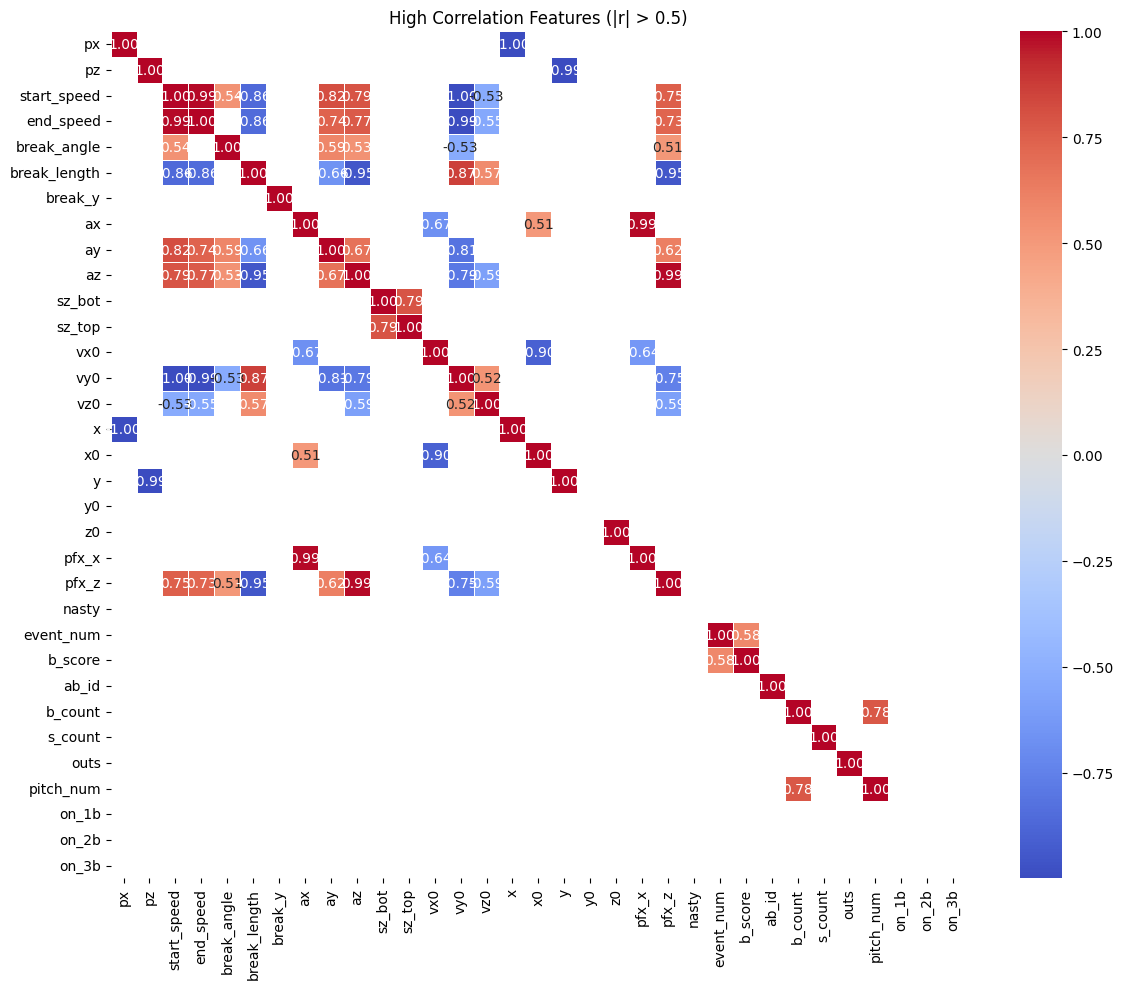

In [119]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

corr = pitch_df.corr(numeric_only=True)

# Create a mask — True means the cell will be hidden
mask = corr.abs() < 0.5  # hide anything with |r| < 0.5

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("High Correlation Features (|r| > 0.5)")
plt.tight_layout()
plt.show()

In [120]:
print("All Features:")
list(pitch_df.columns)

All Features:


['px',
 'pz',
 'start_speed',
 'end_speed',
 'spin_rate',
 'spin_dir',
 'break_angle',
 'break_length',
 'break_y',
 'ax',
 'ay',
 'az',
 'sz_bot',
 'sz_top',
 'type_confidence',
 'vx0',
 'vy0',
 'vz0',
 'x',
 'x0',
 'y',
 'y0',
 'z0',
 'pfx_x',
 'pfx_z',
 'nasty',
 'zone',
 'code',
 'type',
 'pitch_type',
 'event_num',
 'b_score',
 'ab_id',
 'b_count',
 's_count',
 'outs',
 'pitch_num',
 'on_1b',
 'on_2b',
 'on_3b']

In [121]:
# B = Ball, S = Swinging Strike, F = Foul, X = In Play Out, D = In play no out, C = Called Strike
main_outcomes = ['B', 'S', 'F', 'X', 'D', 'C']

# filter to only main outcome types
pitch_df = pitch_df[pitch_df['code'].isin(main_outcomes)].copy()
pitch_df

,px,pz,start_speed,end_speed,spin_rate,spin_dir,break_angle,break_length,break_y,ax,...,event_num,b_score,ab_id,b_count,s_count,outs,pitch_num,on_1b,on_2b,on_3b
0,0.00,2.15,88.8,80.7,placeholder,placeholder,22.8,4.8,24.0,-8.47,...,5,0.0,2.019000e+09,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.34,2.31,89.9,81.8,placeholder,placeholder,22.8,3.6,24.0,-7.10,...,8,0.0,2.019000e+09,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2,-0.05,2.03,85.7,79.6,placeholder,placeholder,9.6,6.0,24.0,3.65,...,9,0.0,2.019000e+09,0.0,0.0,1.0,2.0,0.0,0.0,0.0
3,0.49,0.92,85.4,78.5,placeholder,placeholder,24.0,7.2,24.0,-13.77,...,10,0.0,2.019000e+09,0.0,1.0,1.0,3.0,0.0,0.0,0.0
4,-0.13,1.11,84.6,77.6,placeholder,placeholder,26.4,8.4,24.0,-15.99,...,11,0.0,2.019000e+09,1.0,1.0,1.0,4.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
728785,0.30,1.99,95.8,87.3,placeholder,placeholder,40.8,3.6,24.0,-13.45,...,500,1.0,2.019185e+09,2.0,0.0,1.0,4.0,0.0,0.0,0.0
728786,1.00,-0.38,87.2,80.3,placeholder,placeholder,7.2,7.2,24.0,-5.16,...,503,1.0,2.019185e+09,0.0,0.0,2.0,1.0,0.0,0.0,0.0
728787,0.36,2.02,95.0,86.6,placeholder,placeholder,33.6,3.6,24.0,-10.91,...,504,1.0,2.019185e+09,1.0,0.0,2.0,2.0,0.0,0.0,0.0
728788,-0.26,2.60,84.0,75.3,placeholder,placeholder,2.4,8.4,24.0,-2.69,...,505,1.0,2.019185e+09,1.0,0.0,2.0,3.0,0.0,0.0,0.0


In [122]:
# Initial list of features:
features = ['start_speed', 'pfx_x', 'pfx_z', 'b_count', 's_count', 'outs']

# Encode pitch type (changeup, Fastball, etc) into integers
pitch_type_encoder = LabelEncoder()

# If Pitch type = NA, fill with Fastball code (default pitch)
pitch_df['pitch_type_enc'] = pitch_type_encoder.fit_transform(pitch_df['pitch_type'].fillna('FF'))
features.append('pitch_type_enc')

# Encode outcomes (# B = Ball, S = Swinging Strike, F = Foul, X = In Play Out, D = In play no out, C = Called Strike)
outcome_encoder = LabelEncoder()
pitch_df['outcome_enc'] = outcome_encoder.fit_transform(pitch_df['type'])
outcome_labels = outcome_encoder.classes_

# Batter-specific strike zone — uses each batter's personal sz_bot/sz_top
# rather than a fixed zone, so it accounts for batter height differences
pitch_df['in_batter_zone'] = (
    (pitch_df['pz'] >= pitch_df['sz_bot']) &
    (pitch_df['pz'] <= pitch_df['sz_top']) &
    (pitch_df['px'] >= -0.85) &
    (pitch_df['px'] <= 0.85)
).astype(int)
features.append('in_batter_zone')

# Still include pitch location information - how far it is from the center of strike zone
pitch_df['distance_from_zone'] = np.sqrt(pitch_df['px']**2 + (pitch_df['pz'] - 2.5)**2)
features.append('distance_from_zone')

# for missing values, fill with the median value of non na values in column
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(pitch_df[features]), columns=features)
y = pitch_df['outcome_enc']

X

,start_speed,pfx_x,pfx_z,b_count,s_count,outs,pitch_type_enc,in_batter_zone,distance_from_zone
0,88.8,-5.07,9.98,0.0,0.0,0.0,4.0,1.0,0.350000
1,89.9,-4.14,11.18,0.0,0.0,1.0,4.0,1.0,0.389487
2,85.7,2.30,5.99,0.0,0.0,1.0,11.0,1.0,0.472652
3,85.4,-8.87,4.14,0.0,1.0,1.0,0.0,0.0,1.654237
4,84.6,-10.51,2.51,1.0,1.0,1.0,0.0,0.0,1.396066
...,...,...,...,...,...,...,...,...,...
675635,95.8,-6.90,10.64,2.0,0.0,1.0,4.0,1.0,0.591692
675636,87.2,-3.20,3.00,0.0,0.0,2.0,11.0,0.0,3.048672
675637,95.0,-5.68,10.65,1.0,0.0,2.0,4.0,1.0,0.600000
675638,84.0,-1.84,1.31,1.0,0.0,2.0,11.0,1.0,0.278568


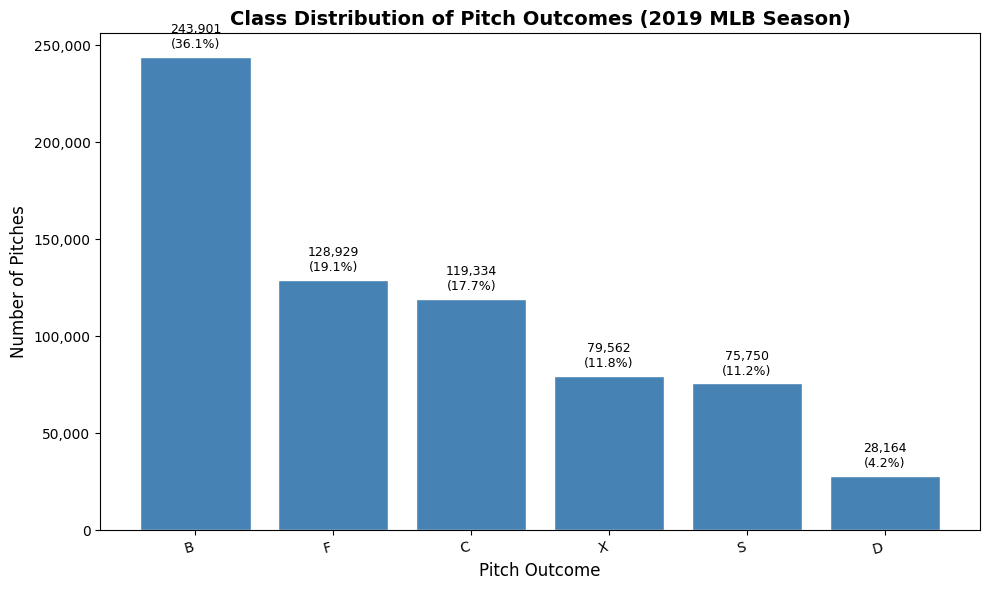


Class Distribution Summary:
Outcome                   Count   Percentage
--------------------------------------------
B                       243,901        36.1%
F                       128,929        19.1%
C                       119,334        17.7%
X                        79,562        11.8%
S                        75,750        11.2%
D                        28,164         4.2%

Total (6 classes)       675,640       100.0%


In [123]:
# full outcome labels for readability
graph_labels = {
    'B': 'Ball',
    'S': 'Swinging Strike',
    'F': 'Foul',
    'X': 'In Play (Out)',
    'D': 'In Play (Not Out)',
    'C': 'Called Strike'
}

# filter to 6 outcomes and count each
counts = pitch_df['code'].value_counts()
counts = counts[counts.index.isin(graph_labels.keys())]

# plot
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(counts.index, counts.values, color='steelblue', edgecolor='white')

# add count + percentage labels on top of each bar
total = counts.sum()
for bar, count in zip(bars, counts.values):
    pct = count / total * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3000,
        f'{count:,}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=9
    )

ax.set_title('Class Distribution of Pitch Outcomes (2019 MLB Season)', fontsize=14, fontweight='bold')
ax.set_xlabel('Pitch Outcome', fontsize=12)
ax.set_ylabel('Number of Pitches', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))  # format y axis with commas
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

# print a summary table
print("\nClass Distribution Summary:")
print(f"{'Outcome':<20} {'Count':>10} {'Percentage':>12}")
print("-" * 44)
for label, count in counts.items():
    print(f"{label:<20} {count:>10,} {count/total*100:>11.1f}%")
print(f"\n{'Total (6 classes)':<20} {total:>10,} {'100.0%':>12}")

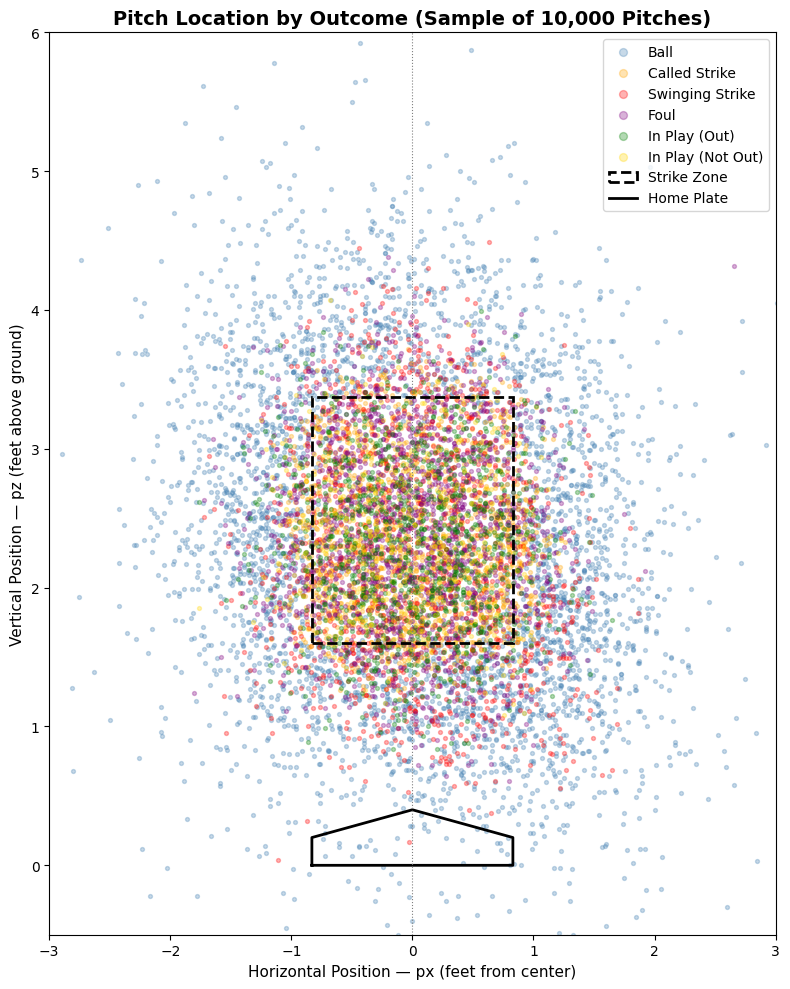

In [124]:
import matplotlib.patches as patches

# outcome labels and colors for each class
outcome_styles = {
    'B': ('Ball','steelblue'),
    'C': ('Called Strike','orange'),
    'S': ('Swinging Strike','red'),
    'F': ('Foul','purple'),
    'X': ('In Play (Out)','green'),
    'D': ('In Play (Not Out)','gold'),
}

# sample the data 
sample = pitch_df.sample(n=10000, random_state=42)

# average strike zone boundaries across all batters
sz_bot = pitch_df['sz_bot'].median()
sz_top = pitch_df['sz_top'].median()

# plot
fig, ax = plt.subplots(figsize=(8, 10))

for code, (label, color) in outcome_styles.items():
    subset = sample[sample['code'] == code]
    ax.scatter(
        subset['px'], subset['pz'],
        label=label, color=color,
        alpha=0.3, s=8
    )

# draw the strike zone box
strike_zone = patches.Rectangle(
    xy=(-0.83, sz_bot),           
    width=1.66,
    height=sz_top - sz_bot,
    linewidth=2,
    edgecolor='black',
    facecolor='none',
    linestyle='--',
    label='Strike Zone'
)
ax.add_patch(strike_zone)

# draw home plate outline for reference
plate_x = [-0.83, 0.83, 0.83, 0, -0.83, -0.83]
plate_y = [0.0,   0.0,  0.2,  0.4, 0.2,   0.0]
ax.plot(plate_x, plate_y, color='black', linewidth=2, label='Home Plate')

ax.set_title('Pitch Location by Outcome (Sample of 10,000 Pitches)', fontsize=14, fontweight='bold')
ax.set_xlabel('Horizontal Position — px (feet from center)', fontsize=11)
ax.set_ylabel('Vertical Position — pz (feet above ground)', fontsize=11)
ax.set_xlim(-3, 3)
ax.set_ylim(-0.5, 6)
ax.axvline(0, color='gray', linestyle=':', linewidth=0.8)  
ax.legend(loc='upper right', markerscale=2)
plt.tight_layout()
plt.show()

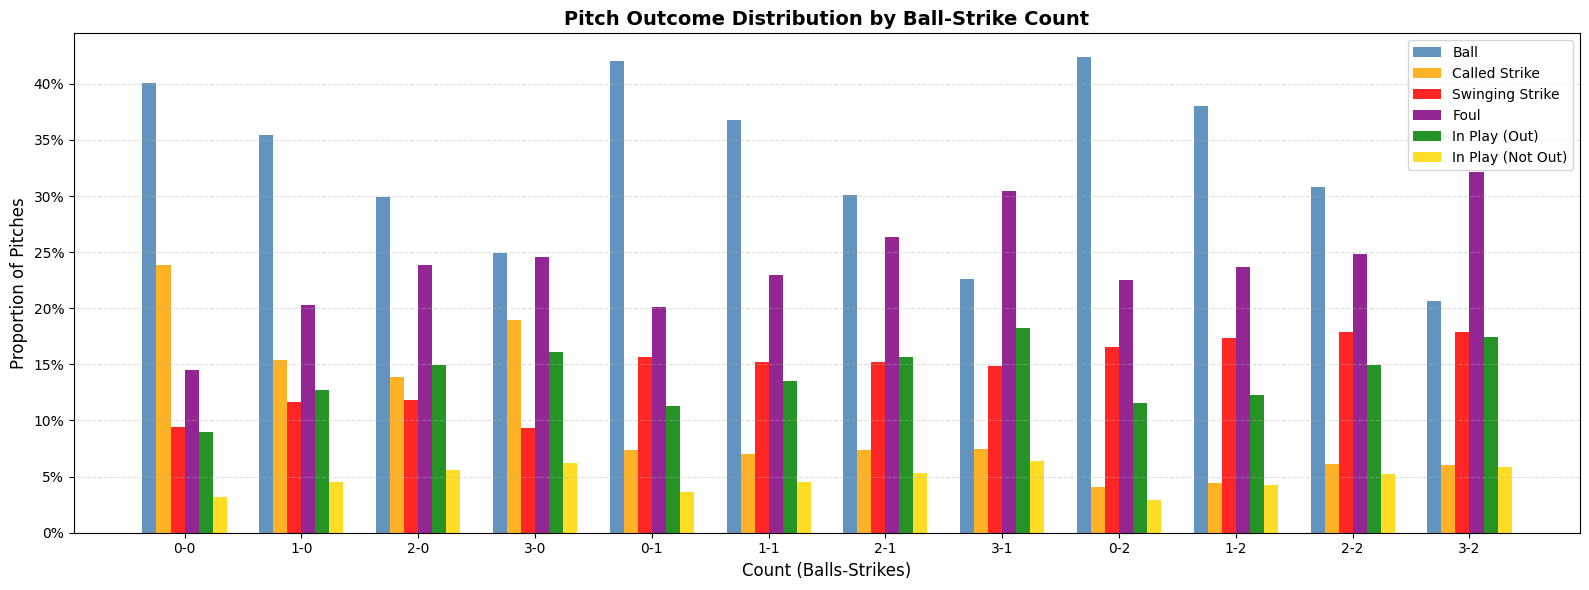

In [125]:

# create a combined pitch count label 
pitch_df['count'] = pitch_df['b_count'].astype(int).astype(str) + '-' + pitch_df['s_count'].astype(int).astype(str)




# get all valid count combinations in a logical order
count_order = ['0-0', '1-0', '2-0', '3-0',
               '0-1', '1-1', '2-1', '3-1',
               '0-2', '1-2', '2-2', '3-2']

# group by count and outcome, then normalize to proportions per count
grouped = pitch_df.groupby(['count', 'code']).size().unstack(fill_value=0)
grouped = grouped.div(grouped.sum(axis=1), axis=0)  
grouped = grouped.reindex(count_order)              
grouped = grouped[[c for c in outcome_styles if c in grouped.columns]]  

#pPlot
n_counts = len(count_order)
n_outcomes = len(outcome_styles)
x = np.arange(n_counts)
width = 0.12  # width of each bar

fig, ax = plt.subplots(figsize=(16, 6))

for i, (code, (label, color)) in enumerate(outcome_styles.items()):
    if code in grouped.columns:
        offset = (i - n_outcomes / 2) * width + width / 2
        ax.bar(x + offset, grouped[code], width, label=label, color=color, alpha=0.85)

ax.set_title('Pitch Outcome Distribution by Ball-Strike Count', fontsize=14, fontweight='bold')
ax.set_xlabel('Count (Balls-Strikes)', fontsize=12)
ax.set_ylabel('Proportion of Pitches', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(count_order)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()



In [126]:
# split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


## Gradient Boosting Classifier

In [127]:
from sklearn.ensemble import GradientBoostingClassifier

In [128]:

gbc = GradientBoostingClassifier(
    max_depth=5,
    learning_rate=.1, 
    n_estimators=100,
    random_state=42    
)

gbc.fit(X_train, y_train)

y_train_pred = gbc.predict(X_train)
y_test_pred = gbc.predict(X_test)
y_train_prob = gbc.predict_proba(X_train) 
y_test_prob = gbc.predict_proba(X_test) 


report_metrics(y_train, y_train_pred, y_train_prob, label="Train")
report_metrics(y_test,  y_test_pred, y_test_prob, label="Test")



--- Train Metrics (weighted) ---
  Error:     0.4639
  Accuracy:  0.5361
  Precision: 0.5175
  Recall:    0.5361
  F1 Score:  0.4595
  CKS:       0.3649
  AUC:       0.8193
  CEL:       1.1882

--- Test Metrics (weighted) ---
  Error:     0.4691
  Accuracy:  0.5309
  Precision: 0.4575
  Recall:    0.5309
  F1 Score:  0.4535
  CKS:       0.3576
  AUC:       0.8143
  CEL:       1.2000



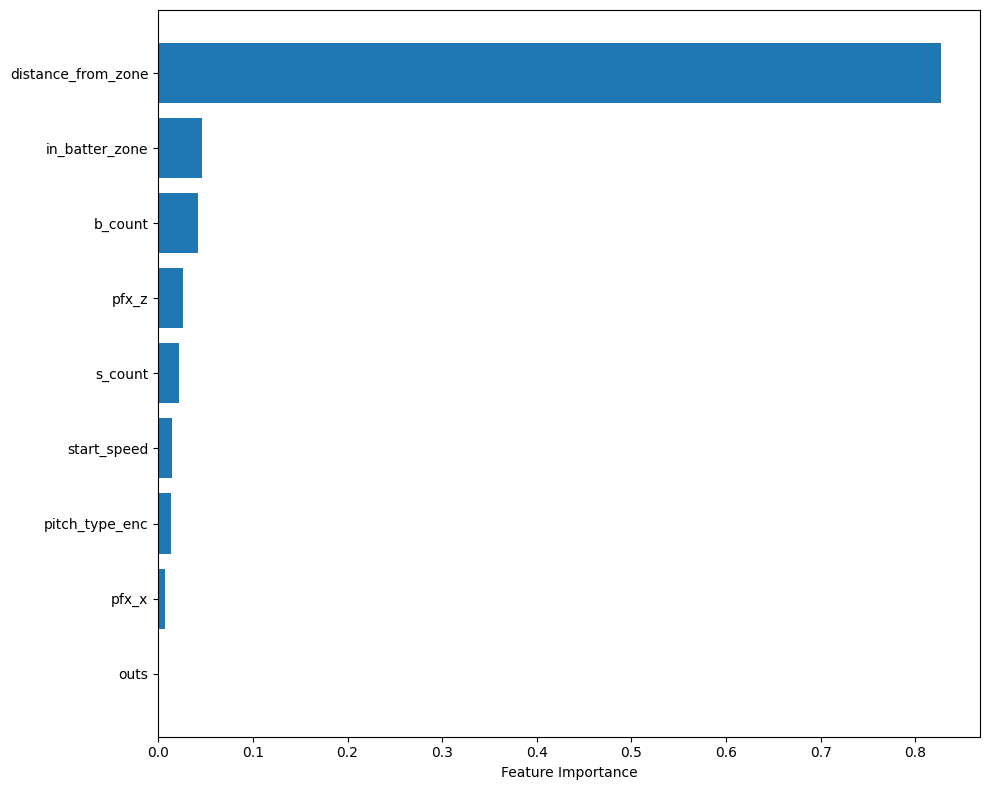

In [135]:
importances = gbc.feature_importances_
sorted_idx = importances.argsort()

plt.figure(figsize=(10, 8))
plt.barh(np.array(features)[sorted_idx], importances[sorted_idx])
plt.xlabel('Feature Importance')
plt.tight_layout()

## Neural Network

In [129]:
## MLP 
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device)

scaler = StandardScaler()
X_train_np = scaler.fit_transform(X_train.values)
X_test_np = scaler.transform(X_test.values)
y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()

input_dim = X_train_np.shape[1]
num_classes = int(y_train_np.max()) + 1

X_train_t = torch.tensor(X_train_np, dtype=torch.float32)
y_train_t = torch.tensor(y_train_np, dtype=torch.long)
X_test_t = torch.tensor(X_test_np, dtype=torch.float32)

class MLP(nn.Module):
    def __init__(self, in_dim, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        return self.net(x)

model = MLP(input_dim, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

batch_size = 4096
train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

epochs = 5
model.train()
for epoch in range(epochs):
    epoch_loss = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    print(f"MLP epoch {epoch + 1}/{epochs} — loss: {epoch_loss / len(train_ds):.4f}")

def predict_proba_in_batches(X_tensor, model, device, batch_size=8192):
    model.eval()
    out = []
    with torch.no_grad():
        for i in range(0, len(X_tensor), batch_size):
            xb = X_tensor[i : i + batch_size].to(device)
            logits = model(xb)
            out.append(torch.softmax(logits, dim=1).cpu().numpy())
    return np.vstack(out)

y_train_prob_mlp = predict_proba_in_batches(X_train_t, model, device)
y_test_prob_mlp = predict_proba_in_batches(X_test_t, model, device)
y_train_pred_mlp = y_train_prob_mlp.argmax(axis=1)
y_test_pred_mlp = y_test_prob_mlp.argmax(axis=1)

report_metrics(y_train, y_train_pred_mlp, y_train_prob_mlp, label="Train (MLP)")
report_metrics(y_test, y_test_pred_mlp, y_test_prob_mlp, label="Test (MLP)")



device: mps
MLP epoch 1/5 — loss: 1.2996
MLP epoch 2/5 — loss: 1.2268
MLP epoch 3/5 — loss: 1.2221
MLP epoch 4/5 — loss: 1.2189
MLP epoch 5/5 — loss: 1.2164
--- Train (MLP) Metrics (weighted) ---
  Error:     0.4698
  Accuracy:  0.5302
  Precision: 0.4387
  Recall:    0.5302
  F1 Score:  0.4453
  CKS:       0.3553
  AUC:       0.8114
  CEL:       1.2056

--- Test (MLP) Metrics (weighted) ---
  Error:     0.4705
  Accuracy:  0.5295
  Precision: 0.4486
  Recall:    0.5295
  F1 Score:  0.4448
  CKS:       0.3543
  AUC:       0.8117
  CEL:       1.2051



## Linear Discriminant Analysis

In [130]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import pandas as pd

## fit LDA model
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

## predictions
y_train_pred_lda = lda.predict(X_train)
y_test_pred_lda  = lda.predict(X_test)

y_train_prob_lda = lda.predict_proba(X_train)
y_test_prob_lda  = lda.predict_proba(X_test)

## print metrics
report_metrics(y_train, y_train_pred_lda, y_train_prob_lda, label="Train (LDA)")
report_metrics(y_test,  y_test_pred_lda,  y_test_prob_lda,  label="Test (LDA)")

--- Train (LDA) Metrics (weighted) ---
  Error:     0.4854
  Accuracy:  0.5146
  Precision: 0.4181
  Recall:    0.5146
  F1 Score:  0.4294
  CKS:       0.3297
  AUC:       0.7945
  CEL:       1.2589

--- Test (LDA) Metrics (weighted) ---
  Error:     0.4850
  Accuracy:  0.5150
  Precision: 0.4210
  Recall:    0.5150
  F1 Score:  0.4299
  CKS:       0.3300
  AUC:       0.7956
  CEL:       1.2569



## Logistic Regression

In [131]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

log_reg_multinomial = LogisticRegression(solver='lbfgs', max_iter=200)
log_reg_OVR = OneVsRestClassifier(LogisticRegression(max_iter=200))

log_reg_multinomial.fit(X_train, y_train)
log_reg_OVR.fit(X_train, y_train)

## predictions (MULTI)
y_train_pred_mult = log_reg_multinomial.predict(X_train)
y_test_pred_mult  = log_reg_multinomial.predict(X_test)

y_train_prob_mult = log_reg_multinomial.predict_proba(X_train)
y_test_prob_mult  = log_reg_multinomial.predict_proba(X_test)

## predictions (OVR)
y_train_pred_ovr = log_reg_OVR.predict(X_train)
y_test_pred_ovr  = log_reg_OVR.predict(X_test)

y_train_prob_ovr = log_reg_OVR.predict_proba(X_train)
y_test_prob_ovr  = log_reg_OVR.predict_proba(X_test)

## print metrics (MULT and OVR)
report_metrics(y_train, y_train_pred_mult, y_train_prob_mult, label="Train (MULTI)")
report_metrics(y_test,  y_test_pred_mult,  y_test_prob_mult,  label="Test (MULTI)")
report_metrics(y_train, y_train_pred_ovr, y_train_prob_ovr, label="Train (OVR)")
report_metrics(y_test,  y_test_pred_ovr,  y_test_prob_ovr,  label="Test (OVR)")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
   

--- Train (MULTI) Metrics (weighted) ---
  Error:     0.4856
  Accuracy:  0.5144
  Precision: 0.4152
  Recall:    0.5144
  F1 Score:  0.4254
  CKS:       0.3288
  AUC:       0.7931
  CEL:       1.2526

--- Test (MULTI) Metrics (weighted) ---
  Error:     0.4855
  Accuracy:  0.5145
  Precision: 0.4155
  Recall:    0.5145
  F1 Score:  0.4255
  CKS:       0.3287
  AUC:       0.7942
  CEL:       1.2506

--- Train (OVR) Metrics (weighted) ---
  Error:     0.4819
  Accuracy:  0.5181
  Precision: 0.4214
  Recall:    0.5181
  F1 Score:  0.4299
  CKS:       0.3346
  AUC:       0.7950
  CEL:       1.2554

--- Test (OVR) Metrics (weighted) ---
  Error:     0.4811
  Accuracy:  0.5189
  Precision: 0.4330
  Recall:    0.5189
  F1 Score:  0.4308
  CKS:       0.3354
  AUC:       0.7958
  CEL:       1.2545



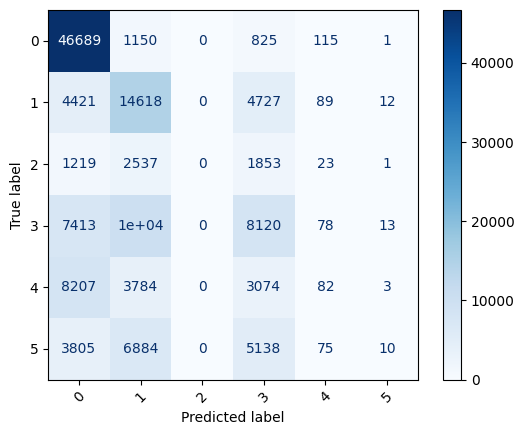

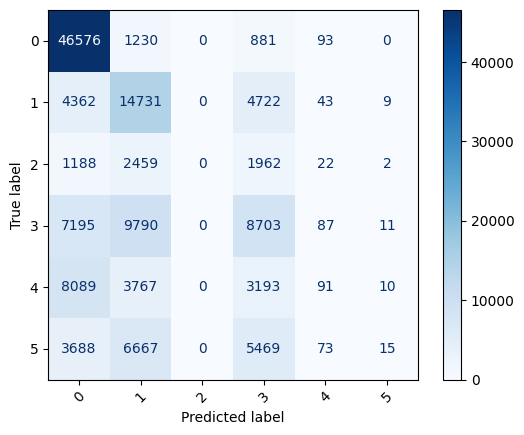

In [132]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(log_reg_multinomial, X_test, y_test, cmap='Blues', xticks_rotation=45)
ConfusionMatrixDisplay.from_estimator(log_reg_OVR, X_test, y_test, cmap='Blues', xticks_rotation=45)

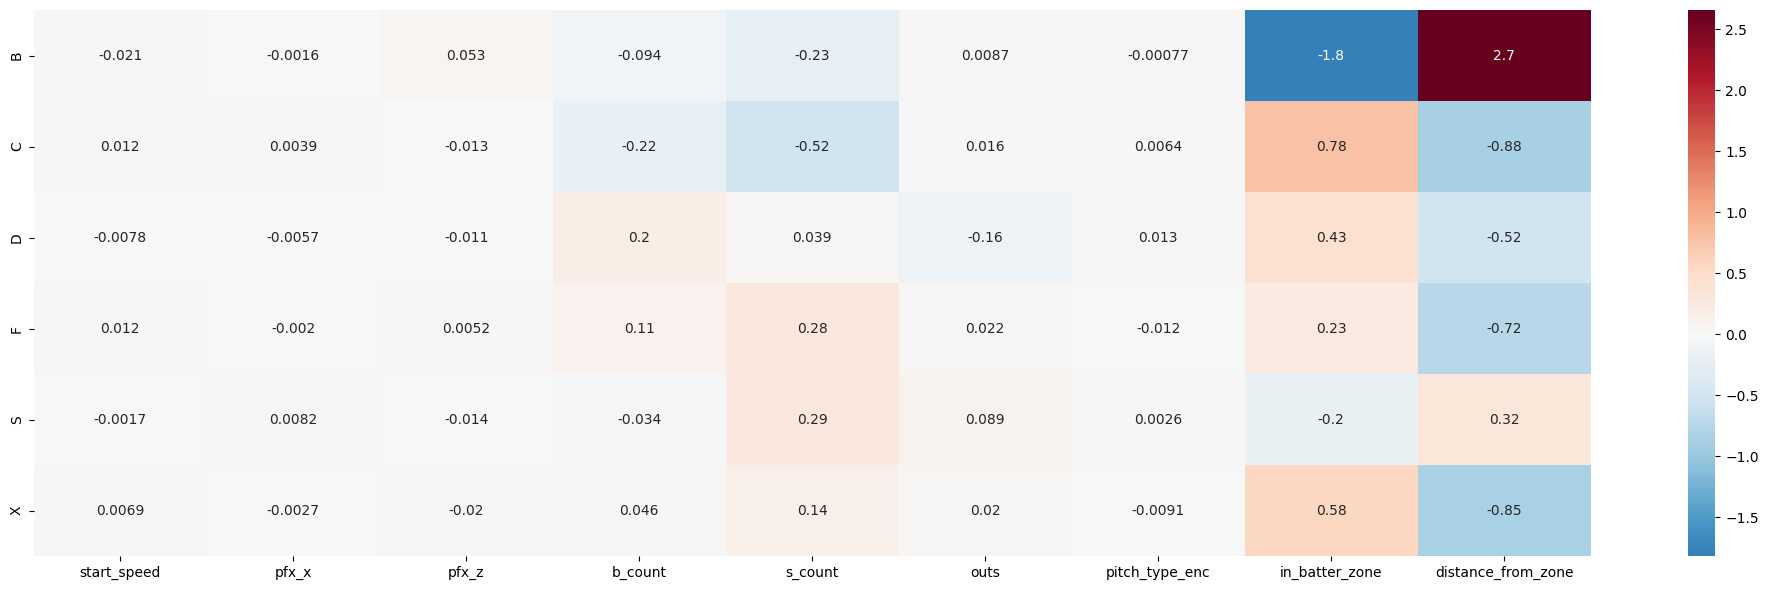

In [133]:
yticklabels = outcome_encoder.inverse_transform(log_reg_multinomial.classes_)

plt.figure(figsize=(20, 6))  # width, height in inches
coef_df = pd.DataFrame(log_reg_multinomial.coef_, index=log_reg_multinomial.classes_, columns=features)
sns.heatmap(coef_df, annot=True, cmap='RdBu_r', center=0, yticklabels=yticklabels)
plt.tight_layout()
